# Residual Signal Finder V2 on UCI credit data

This notebook demonstrates `ResidualSignalFinderV2`, the stability-oriented residual
signal finder. It uses the UCI **Default of Credit Card Clients** dataset and mirrors
the original residual finder walkthrough while emphasizing the V2 workflow:

1. Fit a simple GLM-style base model and create out-of-fold base predictions.
2. Define residuals as `actual - base_prediction`.
3. Run optional multivariate screening with permutation importance.
4. Score candidate features with univariate residual lift across repeated splits.
5. Review residual lift, rank stability, Spearman direction, effect-curve stability, and null/shadow baselines.
6. Inspect variance signal (`abs_oof_r2`): lift on `|residuals|` surfaces heteroscedasticity separately from mean signal.
7. Filter features by `null_beat_rate`: per-feature null comparison using each feature's own permuted copy.
8. Export a self-contained HTML report with `to_html()`.

## Setup

The path setup lets the notebook run from the repository root or from inside
`notebooks/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

for path in [PROJECT_ROOT / 'src', PROJECT_ROOT]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

PROJECT_ROOT

WindowsPath('C:/Users/amsac/Desktop/repos/modeling-tools')

In [2]:
import warnings

import matplotlib
%matplotlib inline

import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

matplotlib.use('Agg')
import matplotlib.pyplot as plt

from pe_tools.signal_finder import ResidualSignalFinderV2

warnings.filterwarnings('ignore', category=ConvergenceWarning)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

## Load the UCI credit dataset

The saved CSV has 30,000 rows and 23 numeric modeling features after dropping the
target. V2 can also evaluate categorical candidate features, so this walkthrough adds
a simple `age_band` feature for diagnostics.

In [3]:
DATA_PATH = PROJECT_ROOT / 'data' / 'default_of_credit_card_clients.csv'
credit = pd.read_csv(DATA_PATH)
target_col = 'default_next_month'
base_feature_cols = [column for column in credit.columns if column != target_col]

print(f'Rows: {len(credit):,}')
print(f'Base feature count: {len(base_feature_cols)}')
display(credit.head())
display(credit[target_col].value_counts(normalize=True).rename('target_rate'))

Rows: 30,000
Base feature count: 23


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


default_next_month
0    0.7788
1    0.2212
Name: target_rate, dtype: float64

## Create a fast analysis sample

The full data remain in `data/`; the notebook uses a stratified sample so V2's
bootstrap diagnostics run quickly. Explicit train/validation/holdout index sets are
created later to demonstrate the `splits=` API for TVH workflows.

In [4]:
analysis_frame = train_test_split(
    credit,
    train_size=2_500,
    stratify=credit[target_col],
    random_state=42,
)[0].sort_index()

train_valid, holdout_rows = train_test_split(
    analysis_frame,
    test_size=0.15,
    stratify=analysis_frame[target_col],
    random_state=42,
)
train_rows, validation_rows = train_test_split(
    train_valid,
    test_size=0.1765,
    stratify=train_valid[target_col],
    random_state=42,
)

X_base = analysis_frame.loc[:, base_feature_cols].copy()
y_true = analysis_frame[target_col].astype(float).rename(target_col)
split_label = pd.Series('train', index=X_base.index, name='split')
split_label.loc[validation_rows.index] = 'validation'
split_label.loc[holdout_rows.index] = 'holdout'

split_summary = pd.concat(
    [
        split_label.value_counts().rename('rows'),
        y_true.groupby(split_label).mean().rename('event_rate'),
    ],
    axis=1,
)
display(split_summary)

,rows,event_rate
split,,
train,1749,0.221269
validation,376,0.220745
holdout,375,0.221333


## Build sample weights and candidate features

Weights are optional. Here they balance the minority default class and mildly emphasize
larger credit limits. `age_band` is intentionally not part of the base GLM, so V2 can
show how a new candidate feature is handled.

In [5]:
default_rate = float(y_true.mean())
class_weight = np.where(
    y_true.eq(1),
    0.5 / default_rate,
    0.5 / (1.0 - default_rate),
)
limit_weight = (X_base['limit_bal'] / X_base['limit_bal'].median()).clip(0.25, 4.0)
sample_weight = pd.Series(
    class_weight * limit_weight.to_numpy(),
    index=X_base.index,
    name='sample_weight',
)

X_candidates = X_base.copy()
X_candidates['age_band'] = pd.cut(
    X_base['age'],
    bins=[20, 30, 40, 50, 60, 80],
    include_lowest=True,
).astype(str)

print(f'Candidate feature count: {X_candidates.shape[1]}')
display(sample_weight.describe())
display(X_candidates[['age', 'age_band', 'limit_bal', 'pay_0']].head())

Candidate feature count: 24


count    2500.000000
mean        1.117628
std         1.143813
min         0.160503
25%         0.412723
50%         0.807285
75%         1.375743
max         8.880134
Name: sample_weight, dtype: float64

,age,age_band,limit_bal,pay_0
40,33,"(30.0, 40.0]",360000,0
44,30,"(19.999, 30.0]",40000,0
48,32,"(30.0, 40.0]",380000,-1
58,34,"(30.0, 40.0]",200000,-1
72,32,"(30.0, 40.0]",200000,-1


## Create out-of-fold base predictions

V2 assumes `base_pred` is preferably out-of-fold or out-of-sample. This cell creates
OOF predictions from a simple standardized logistic regression that uses all numeric
base features.

In [6]:
oof_pred = pd.Series(np.nan, index=X_base.index, name='oof_default_probability')
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

for fold, (train_idx, validation_idx) in enumerate(cv.split(X_base, y_true), start=1):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1_000, solver='lbfgs'),
    )
    model.fit(
        X_base.iloc[train_idx],
        y_true.iloc[train_idx],
        logisticregression__sample_weight=sample_weight.iloc[train_idx],
    )
    oof_pred.iloc[validation_idx] = model.predict_proba(X_base.iloc[validation_idx])[:, 1]
    fold_auc = roc_auc_score(y_true.iloc[validation_idx], oof_pred.iloc[validation_idx])
    print(f'Fold {fold} ROC AUC: {fold_auc:.3f}')

print(f'OOF ROC AUC: {roc_auc_score(y_true, oof_pred):.3f}')
display(pd.DataFrame({'actual': y_true, 'base_pred': oof_pred}).head())

Fold 1 ROC AUC: 0.716
Fold 2 ROC AUC: 0.724
Fold 3 ROC AUC: 0.741
Fold 4 ROC AUC: 0.685
OOF ROC AUC: 0.715


,actual,base_pred
40,0.0,0.428634
44,0.0,0.655529
48,0.0,0.157509
58,0.0,0.430265
72,0.0,0.253836


## Fit `ResidualSignalFinderV2`

For notebook speed this run uses random forests with modest tree counts. The same API
supports `univariate_model_type='xgboost'`.

**Key parameters:**
- `n_bootstraps=50` — minimum recommended for stable summaries; warn fires at < 30.
- `n_null_features=5` — one permuted null is created per candidate feature (up to this limit). Each real feature is then compared against **its own** permuted copy, not a pooled shadow pool.
- `subsample_max_train_size` — caps training rows per split for large datasets (e.g. > 100 k). Pair with `subsample_positive_class_target_perc` (default 0.30) when the target is zero-inflated (> 80 % zeros): the subsample will upsample non-zeros to that fraction so minority signal is preserved.
- `split_strategy='repeated_kfold'` with `n_splits=5` gives 20 × 5 = 100 evaluation windows without replacement — useful for smaller samples (< 5 k rows). `'bootstrap'` with `n_bootstraps=50` is the default and suits larger datasets.

In [ ]:
finder = ResidualSignalFinderV2(
    screening_enabled=True,
    screening_model_type='random_forest',
    screening_top_k=15,
    screening_cv_folds=3,
    screening_n_repeats=1,
    univariate_model_type='random_forest',
    split_strategy='bootstrap',
    n_bootstraps=20,
    test_size=0.25, # Train on 0.75, evaluate on 0.25
    n_bins=20,
    random_state=42,
    use_sample_weight=True,
    model_params={'n_estimators': 30, 'max_depth': 1, 'min_samples_leaf': 25},
    # subsample_max_train_size=5_000,  # uncomment for datasets > 100k rows
    # subsample_positive_class_target_perc=0.30,  # non-zero upsampling when > 80% zeros
)

finder.fit(
    X_candidates,
    y=y_true,
    base_pred=oof_pred,
    sample_weight=sample_weight,
    original_model_features=base_feature_cols,
)

summary = finder.get_summary()
display(pd.Series(finder.residual_summary_, name='value').to_frame())
display(finder.warnings_)

,value
mean_residual,-0.221708
median_residual,-0.355644
std_residual,0.396720
mae_residual,0.419953
rmse_residual,0.454468
residual_skew,1.051044
residual_kurtosis,0.077113


['Residual diagnostics are most reliable when base_pred contains out-of-fold or out-of-sample predictions. In-sample predictions can hide residual signal or create misleading artifacts.',
 'n_bootstraps < 50; stability summaries are directional, not final.']

## Feature summary

The summary is sorted by `mean_oof_residual_r2` (mean-signal lift). New columns added
in the latest version:

- `mean_oof_abs_residual_r2` / `median_oof_abs_residual_r2`: lift on `|residuals|`.
  A feature that predicts **variance** of errors (not just mean shift) will show up here
  even when `mean_oof_residual_r2` is low.
- `null_beat_rate`: fraction of bootstrap runs in which the real feature's OOF R²
  exceeded its **own** permuted null. A rate > 0.75 is a credibility threshold.

In [8]:
mean_signal_cols = [
    'feature', 'feature_type',
    'mean_oof_residual_r2', 'p05_oof_residual_r2', 'p95_oof_residual_r2',
    'null_beat_rate',
    'mean_oof_abs_residual_r2',
    'median_effect_curve_spearman_stability',
    'pct_positive_feature_residual_spearman',
]
display(summary[mean_signal_cols].head(10))

,feature,feature_type,mean_oof_residual_r2,p05_oof_residual_r2,p95_oof_residual_r2,null_beat_rate,mean_oof_abs_residual_r2,median_effect_curve_spearman_stability,pct_positive_feature_residual_spearman
0,pay_0,continuous,0.018798,-0.002780,0.039340,0.933333,0.026513,0.766562,0.000000
1,bill_amt1,continuous,0.012315,-0.015472,0.039413,0.800000,0.018181,0.426213,0.066667
2,pay_amt5,continuous,0.011057,-0.017962,0.041440,0.800000,0.011867,0.480303,0.966667
3,pay_2,continuous,0.007704,-0.018403,0.024197,0.800000,0.009804,0.626623,0.000000
4,pay_amt2,continuous,0.007589,-0.027167,0.033963,0.766667,0.036863,0.435398,0.966667
5,pay_5,continuous,0.005596,-0.008662,0.020546,0.800000,-0.002025,0.477960,0.000000
6,pay_6,continuous,0.005229,-0.010792,0.020654,0.800000,-0.003060,0.431818,0.000000
7,pay_3,continuous,0.002716,-0.016791,0.020176,0.633333,-0.002628,0.433442,0.000000
8,pay_4,continuous,0.002176,-0.018951,0.016025,0.766667,0.000784,0.485857,0.000000
9,pay_amt6,continuous,0.001654,-0.028775,0.021980,0.800000,0.000877,0.345133,0.966667


## Variance signal: lift on |residuals|

`mean_oof_abs_residual_r2` answers a different question than `mean_oof_residual_r2`:
does a feature predict *how wrong* the base model is, even if it does not shift the
predicted mean? A feature with high abs-residual lift but near-zero mean-residual lift
indicates heteroscedasticity — the base model's error magnitude varies across the
feature's range, which is exploitable for calibration or uncertainty estimation.

Compare the two lift columns side by side and look for features with a notable gap.

In [9]:
variance_signal_cols = [
    'feature',
    'mean_oof_residual_r2',
    'mean_oof_abs_residual_r2',
    'p05_oof_abs_residual_r2',
    'p95_oof_abs_residual_r2',
]
variance_view = (
    summary[variance_signal_cols]
    .assign(
        abs_minus_mean=lambda df:
            df['mean_oof_abs_residual_r2'] - df['mean_oof_residual_r2']
    )
    .sort_values('mean_oof_abs_residual_r2', ascending=False)
)
print('Features ranked by variance-signal lift (|residual| R²):')
display(variance_view.head(10))

# Features where variance signal is notably stronger than mean signal
variance_dominant = variance_view.loc[
    variance_view['abs_minus_mean'] > 0.005
]
if not variance_dominant.empty:
    print('\nFeatures with variance signal > mean signal by > 0.005 R²:')
    display(variance_dominant)

Features ranked by variance-signal lift (|residual| R²):


,feature,mean_oof_residual_r2,mean_oof_abs_residual_r2,p05_oof_abs_residual_r2,p95_oof_abs_residual_r2,abs_minus_mean
4,pay_amt2,0.007589,0.036863,-0.059441,0.097160,0.029274
0,pay_0,0.018798,0.026513,0.004896,0.049018,0.007715
1,bill_amt1,0.012315,0.018181,-0.017426,0.050175,0.005866
2,pay_amt5,0.011057,0.011867,-0.046838,0.059701,0.000810
3,pay_2,0.007704,0.009804,-0.001920,0.019995,0.002100
9,pay_amt6,0.001654,0.000877,-0.032258,0.030175,-0.000777
8,pay_4,0.002176,0.000784,-0.014651,0.011481,-0.001391
10,sex,-0.002006,-0.001852,-0.010556,0.005049,0.000154
5,pay_5,0.005596,-0.002025,-0.015042,0.006107,-0.007622
7,pay_3,0.002716,-0.002628,-0.020275,0.006833,-0.005344



Features with variance signal > mean signal by > 0.005 R²:


,feature,mean_oof_residual_r2,mean_oof_abs_residual_r2,p05_oof_abs_residual_r2,p95_oof_abs_residual_r2,abs_minus_mean
4,pay_amt2,0.007589,0.036863,-0.059441,0.097160,0.029274
0,pay_0,0.018798,0.026513,0.004896,0.049018,0.007715
1,bill_amt1,0.012315,0.018181,-0.017426,0.050175,0.005866


## Null beat rate: credibility filter

`null_beat_rate` is the fraction of bootstrap runs in which a feature's OOF R²
exceeded its **own** permuted copy's OOF R². Because each feature is compared against
a null that has the same marginal distribution, the comparison is feature-specific and
not affected by heterogeneous feature scales.

- **> 0.75**: consistently beats chance — signal is credible.
- **0.50–0.75**: marginal — investigate stability before acting.
- **< 0.50**: feature does not reliably beat its own noise baseline.

The `beats_null` column in `bootstrap_results_` records the per-run boolean, and
`null_oof_r2` stores the matched null's score for that run.

In [10]:
# Features that consistently beat their own null
credible_features = summary.loc[
    summary['null_beat_rate'].fillna(0) > 0.75,
    ['feature', 'mean_oof_residual_r2', 'null_beat_rate',
     'median_effect_curve_spearman_stability'],
]
print(f'Features with null_beat_rate > 0.75: {len(credible_features)}')
display(credible_features)

# Per-run null comparison for the top feature
top_feature = str(summary.iloc[0]['feature'])
null_run_view = (
    finder.bootstrap_results_
    .loc[
        finder.bootstrap_results_['feature'].eq(top_feature)
        & finder.bootstrap_results_['split_role'].eq('validation'),
        ['bootstrap_id', 'oof_r2', 'abs_oof_r2', 'null_oof_r2', 'beats_null'],
    ]
    .head(10)
)
print(f'\nPer-run null comparison for "{top_feature}":')
display(null_run_view)

Features with null_beat_rate > 0.75: 9


,feature,mean_oof_residual_r2,null_beat_rate,median_effect_curve_spearman_stability
0,pay_0,0.018798,0.933333,0.766562
1,bill_amt1,0.012315,0.800000,0.426213
2,pay_amt5,0.011057,0.800000,0.480303
3,pay_2,0.007704,0.800000,0.626623
4,pay_amt2,0.007589,0.766667,0.435398
5,pay_5,0.005596,0.800000,0.477960
6,pay_6,0.005229,0.800000,0.431818
8,pay_4,0.002176,0.766667,0.485857
9,pay_amt6,0.001654,0.800000,0.345133



Per-run null comparison for "pay_0":


,bootstrap_id,oof_r2,abs_oof_r2,null_oof_r2,beats_null
0,0,0.022580,0.029948,-0.000273,1.0
15,1,0.038692,0.004357,-0.011535,1.0
30,2,0.027585,0.024308,-0.006729,1.0
45,3,0.035850,0.015441,-0.002629,1.0
60,4,0.011136,0.019576,-0.005270,1.0
75,5,0.009088,0.050208,-0.000932,1.0
90,6,0.021538,0.043119,-0.001111,1.0
105,7,-0.005248,-0.009073,-0.002165,0.0
120,8,0.000238,0.036589,-0.003633,1.0
135,9,0.002075,0.013499,-0.023784,1.0


## Inspect V2 result tables

V2 stores feature-level summaries, per-bootstrap scores, effect curves, null-feature
scores, and optional screening results directly on the fitted finder.

The `null_results_` table now stores one row per feature per split (instead of a
pooled pool), matching each null to its source feature by name.

In [11]:
print('Screening results')
display(finder.screening_results_.head(10))

print('Bootstrap results (selected columns)')
bootstrap_cols = [
    'bootstrap_id', 'split_role', 'feature',
    'oof_r2', 'abs_oof_r2', 'null_oof_r2', 'beats_null',
    'spearman', 'rank', 'is_top_5',
]
display(
    finder.bootstrap_results_[
        [c for c in bootstrap_cols if c in finder.bootstrap_results_.columns]
    ].head(10)
)

print('Effect curves (first 5 rows)')
display(finder.effect_curves_.head(5))

print('Null results (per-feature permuted nulls)')
display(finder.null_results_.head(10))

Screening results


,feature,screening_mean_perm_importance,screening_median_perm_importance,screening_importance_std,screening_median_rank,screening_top_5_rate,screening_top_10_rate
0,pay_0,0.005859,0.003241,0.005148,2.0,1.0,1.0
1,bill_amt1,0.011381,0.004778,0.012137,2.0,0.6,0.6
2,pay_amt5,0.000993,0.003340,0.006242,3.0,0.6,0.6
3,pay_amt6,0.000650,0.000107,0.000811,4.0,0.6,0.6
4,pay_amt2,0.000282,0.000099,0.008098,4.0,0.6,0.6
5,limit_bal,0.000000,0.000000,0.000000,5.0,0.8,1.0
6,sex,0.000000,0.000000,0.000000,6.0,0.4,1.0
7,education,0.000000,0.000000,0.000000,7.0,0.2,1.0
8,marriage,0.000000,0.000000,0.000000,8.0,0.0,1.0
9,age,0.000000,0.000000,0.000000,9.0,0.0,1.0


Bootstrap results (selected columns)


,bootstrap_id,split_role,feature,oof_r2,abs_oof_r2,null_oof_r2,beats_null,spearman,rank,is_top_5
0,0,validation,pay_0,0.022580,0.029948,-0.000273,1.0,-0.204030,3.0,True
1,0,validation,bill_amt1,0.018646,0.048207,-0.001889,1.0,-0.038208,4.0,True
2,0,validation,pay_amt5,0.015381,0.037550,0.004422,1.0,0.066660,5.0,True
3,0,validation,pay_amt6,0.003837,0.003792,-0.002528,1.0,0.048293,9.0,False
4,0,validation,pay_amt2,0.026419,0.083640,-0.002698,1.0,0.063139,1.0,True
5,0,validation,limit_bal,-0.006265,-0.042212,-0.000841,0.0,0.090323,14.0,False
6,0,validation,sex,-0.008059,0.004364,0.002662,0.0,0.016234,15.0,False
7,0,validation,education,-0.001072,0.005221,0.003951,0.0,0.080994,12.0,False
8,0,validation,marriage,0.000641,-0.001362,0.000075,1.0,-0.050880,11.0,False
9,0,validation,age,-0.001901,-0.017070,0.001726,0.0,-0.027989,13.0,False


Effect curves (first 5 rows)


,feature,bootstrap_id,split_id,split_role,bin_id,bin_label,bin_left,bin_right,n_obs,reliable,actual_mean,base_prediction_mean,corrected_prediction_mean,mean_residual,centered_mean_residual,predicted_residual,mean_abs_residual
0,pay_0,0,0,validation,0,-2,-2.0,-2.0,41,True,0.392460,0.210789,0.214426,0.181671,0.191655,0.003636,0.420311
1,pay_0,0,0,validation,1,-2,-2.0,-1.0,41,True,0.392460,0.210789,0.214426,0.181671,0.191655,0.003636,0.420311
2,pay_0,0,0,validation,2,-2–-1,-1.0,-1.0,27,True,0.306936,0.271559,0.275196,0.035376,0.045360,0.003636,0.391408
3,pay_0,0,0,validation,3,-1,-1.0,-1.0,80,True,0.424423,0.329058,0.332694,0.095365,0.105349,0.003636,0.431136
4,pay_0,0,0,validation,4,-1,-1.0,-1.0,80,True,0.424423,0.329058,0.332694,0.095365,0.105349,0.003636,0.431136


Null results (per-feature permuted nulls)


,bootstrap_id,split_id,split_role,null_feature,source_feature,oof_r2,rank,mean_effect_curve_spearman_stability,median_effect_curve_spearman_stability,std_effect_curve_spearman_stability
0,0,0,validation,__null_pay_0,pay_0,-0.000273,11.0,0.128150,0.117012,0.384089
1,0,0,validation,__null_bill_amt1,bill_amt1,-0.001889,13.0,0.297063,0.299248,0.195538
2,0,0,validation,__null_pay_amt5,pay_amt5,0.004422,1.0,0.220505,0.245455,0.241858
3,0,0,validation,__null_pay_amt6,pay_amt6,-0.002528,14.0,0.151216,0.157576,0.238520
4,0,0,validation,__null_pay_amt2,pay_amt2,-0.002698,15.0,0.152296,0.155354,0.226861
5,0,0,validation,__null_limit_bal,limit_bal,-0.000841,12.0,0.243272,0.261099,0.222644
6,0,0,validation,__null_sex,sex,0.002662,4.0,0.162046,0.615385,0.847477
7,0,0,validation,__null_education,education,0.003951,2.0,0.130596,0.177172,0.506606
8,0,0,validation,__null_marriage,marriage,0.000075,9.0,0.132157,0.358792,0.633395
9,0,0,validation,__null_age,age,0.001726,6.0,0.211667,0.213534,0.217719


## Feature-level lookup

`get_feature_summary` returns one feature's compact V2 stability row, now including
`null_beat_rate` and the abs-residual R² columns.

In [12]:
top_feature = str(summary.iloc[0]['feature'])
print(f'Top feature: {top_feature}')
display(finder.get_feature_summary(top_feature).to_frame('value'))

Top feature: pay_0


,value
feature,pay_0
feature_type,continuous
n_observations,2500
mean_oof_residual_r2,0.018798
median_oof_residual_r2,0.019877
p05_oof_residual_r2,-0.00278
p95_oof_residual_r2,0.03934
mean_oof_abs_residual_r2,0.026513
median_oof_abs_residual_r2,0.027468
p05_oof_abs_residual_r2,0.004896


## Plot diagnostics for one feature

The five-panel diagnostic figure:

1. **Actual vs. base prediction by bin** — does the base model track the actual mean?
2. **Effect curve stability (p10–p90 band)** — the shaded band shows where bootstrap
   curves agree; a narrow band over a non-flat trend indicates reliable signal.
3. **Pairwise Spearman histogram** — distribution of curve-vs-curve Spearman
   correlations across bootstrap pairs; only bins reliable in ≥ 50 % of runs are used.
4. **Null baseline comparison** — the large percentage is the null beat rate; the strip
   plot shows real (blue) and null (gray) OOF R² scores for each bootstrap run.
5. **Residual scatter** — raw observation-level residuals by feature value.

In [ ]:
figure = finder.plot_feature_diagnostics(top_feature)
display(figure)
plt.close(figure)

ValueError: Categorical categories must be unique

## Plot focused V2 diagnostics

These methods return matplotlib `Figure` objects and do not save files unless you do
so explicitly.

Displaying rank_stability


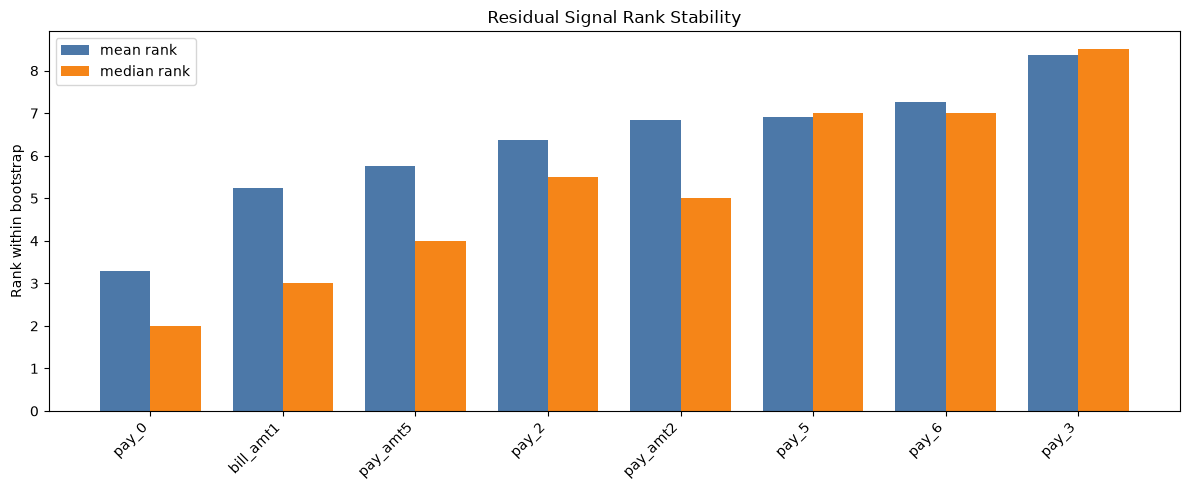

Displaying residual_signal_map


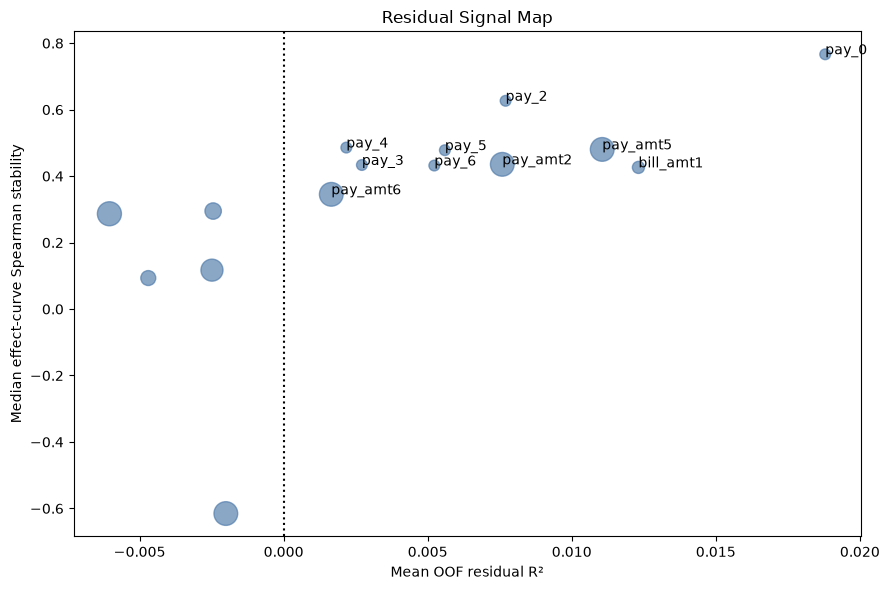

In [ ]:
figures = {
    'rank_stability': finder.plot_rank_stability(n=8),
    'residual_signal_map': finder.plot_residual_signal_map(),
}

for name, figure in figures.items():
    print(f'Displaying {name}')
    display(figure)
    plt.close(figure)

## Plot top features

`plot_top_features` is useful when reviewing several candidates after sorting by
`mean_oof_residual_r2`.

Displaying diagnostics for pay_0


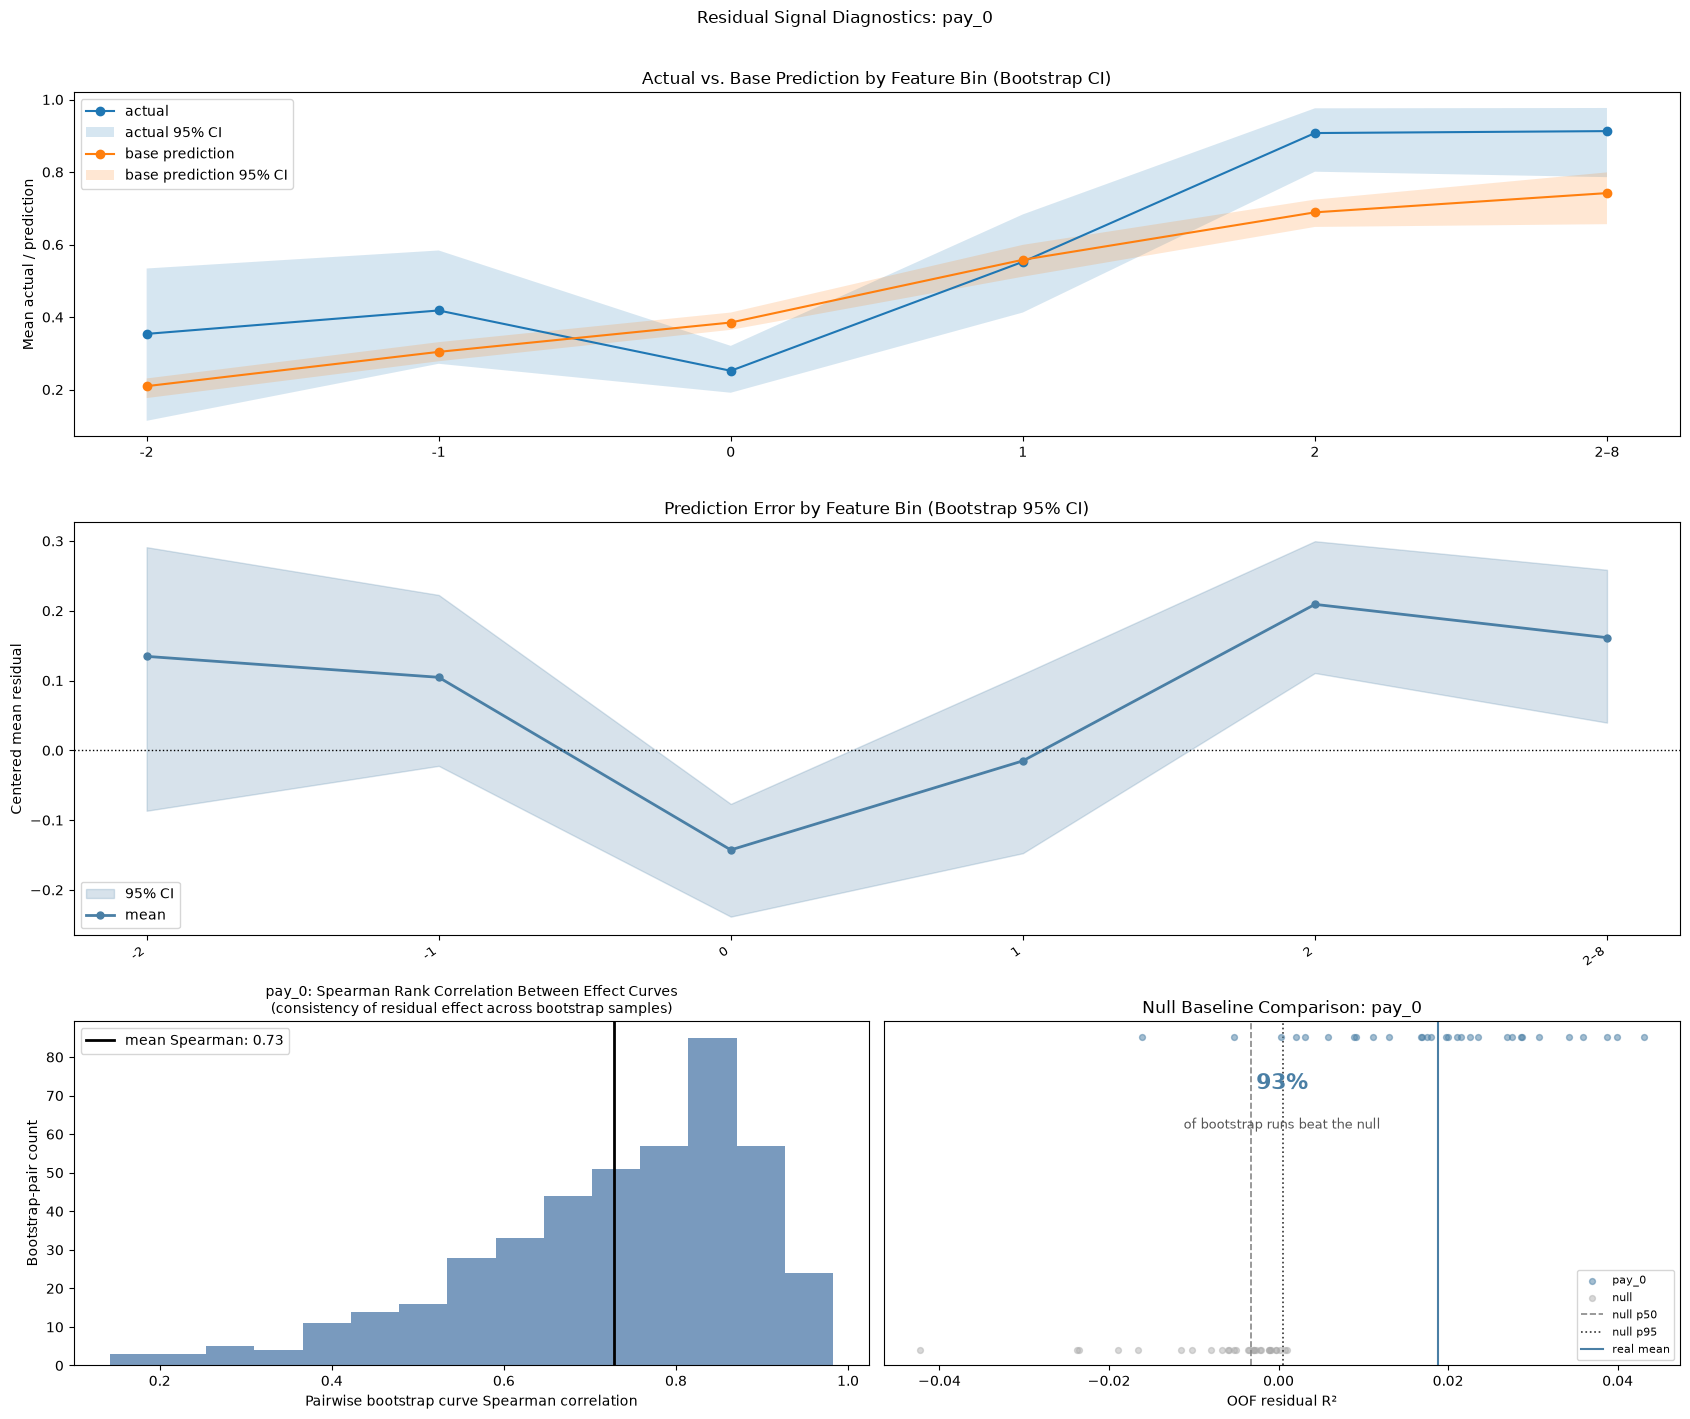

Displaying diagnostics for bill_amt1


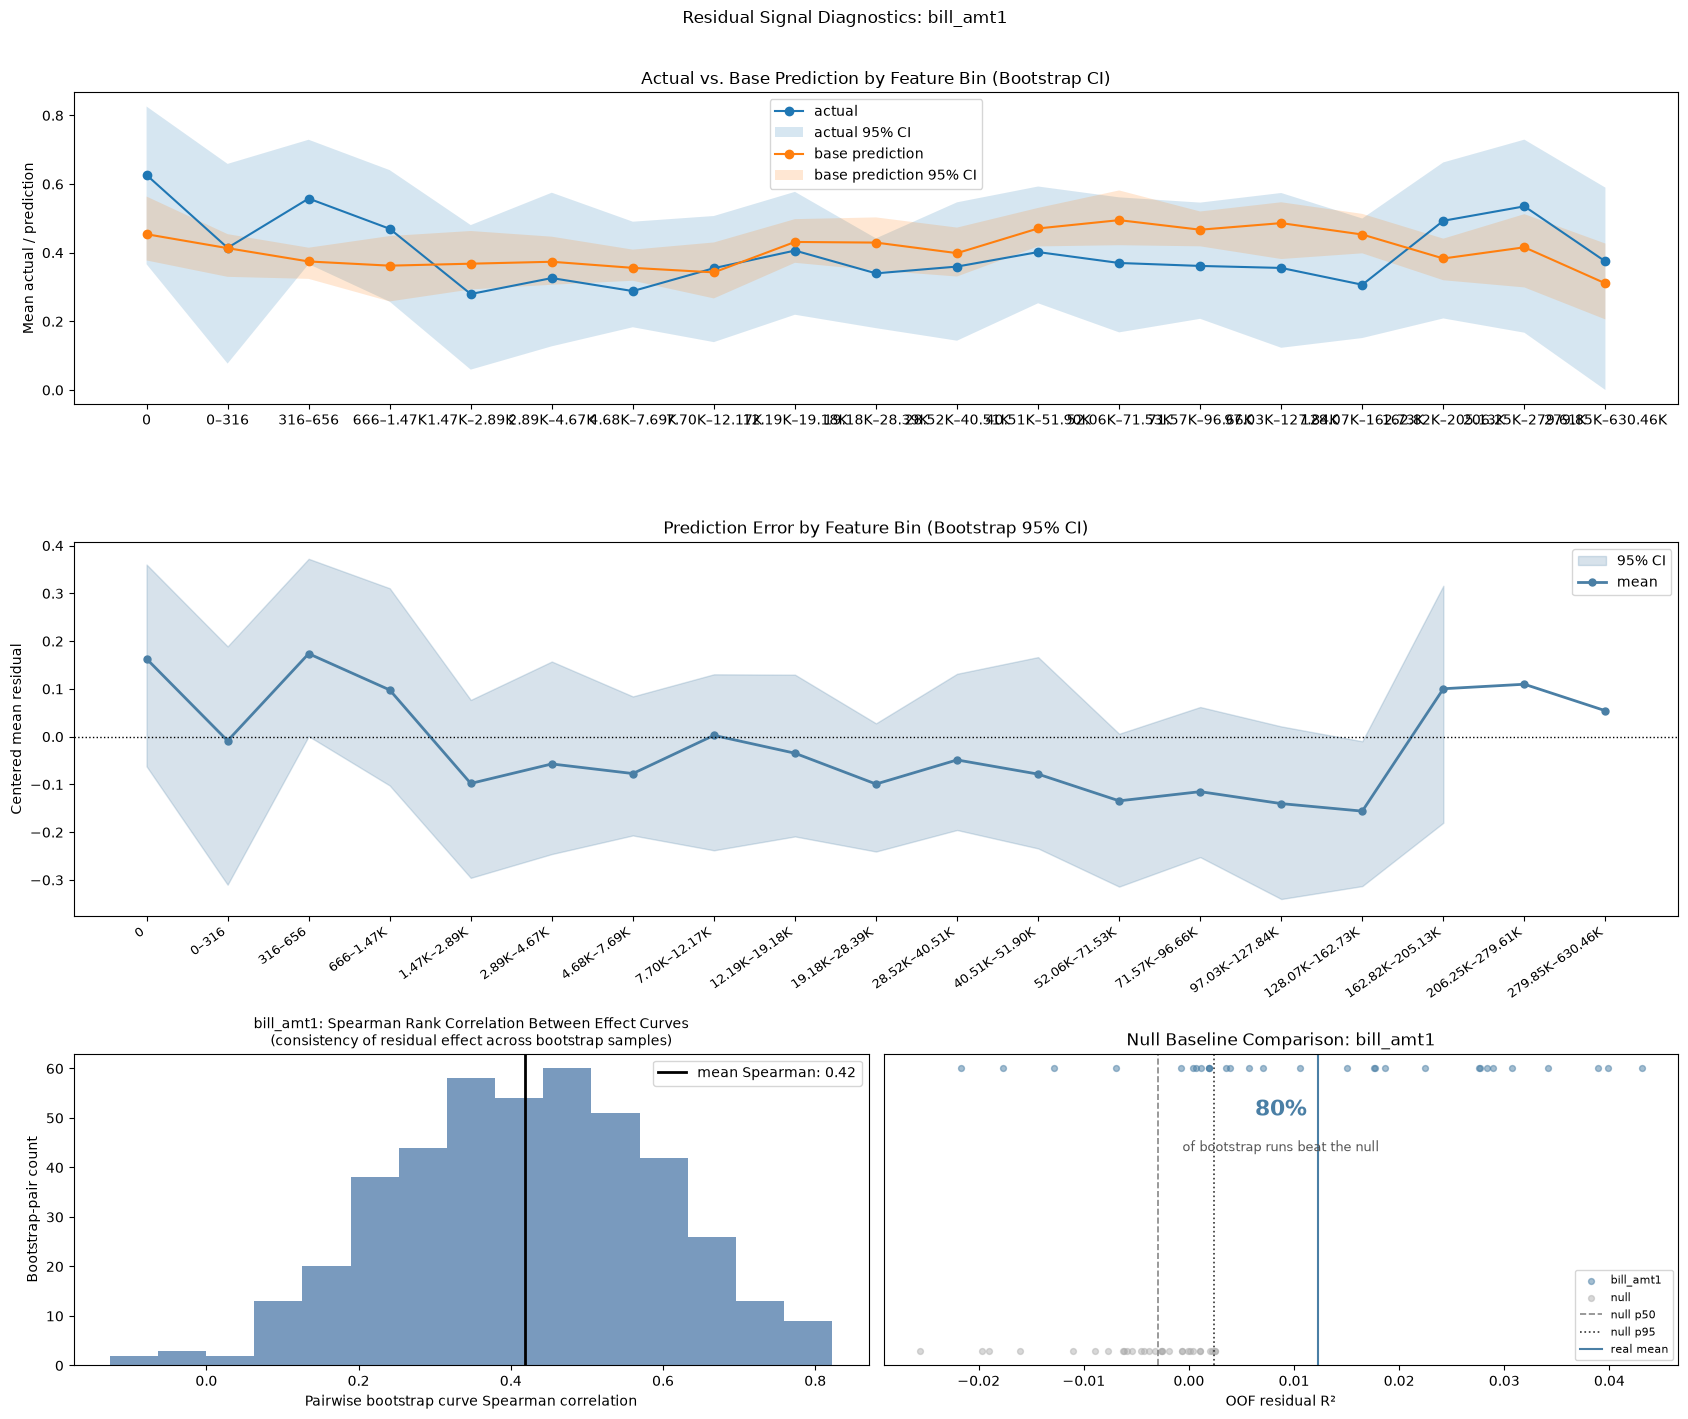

Displaying diagnostics for pay_amt5


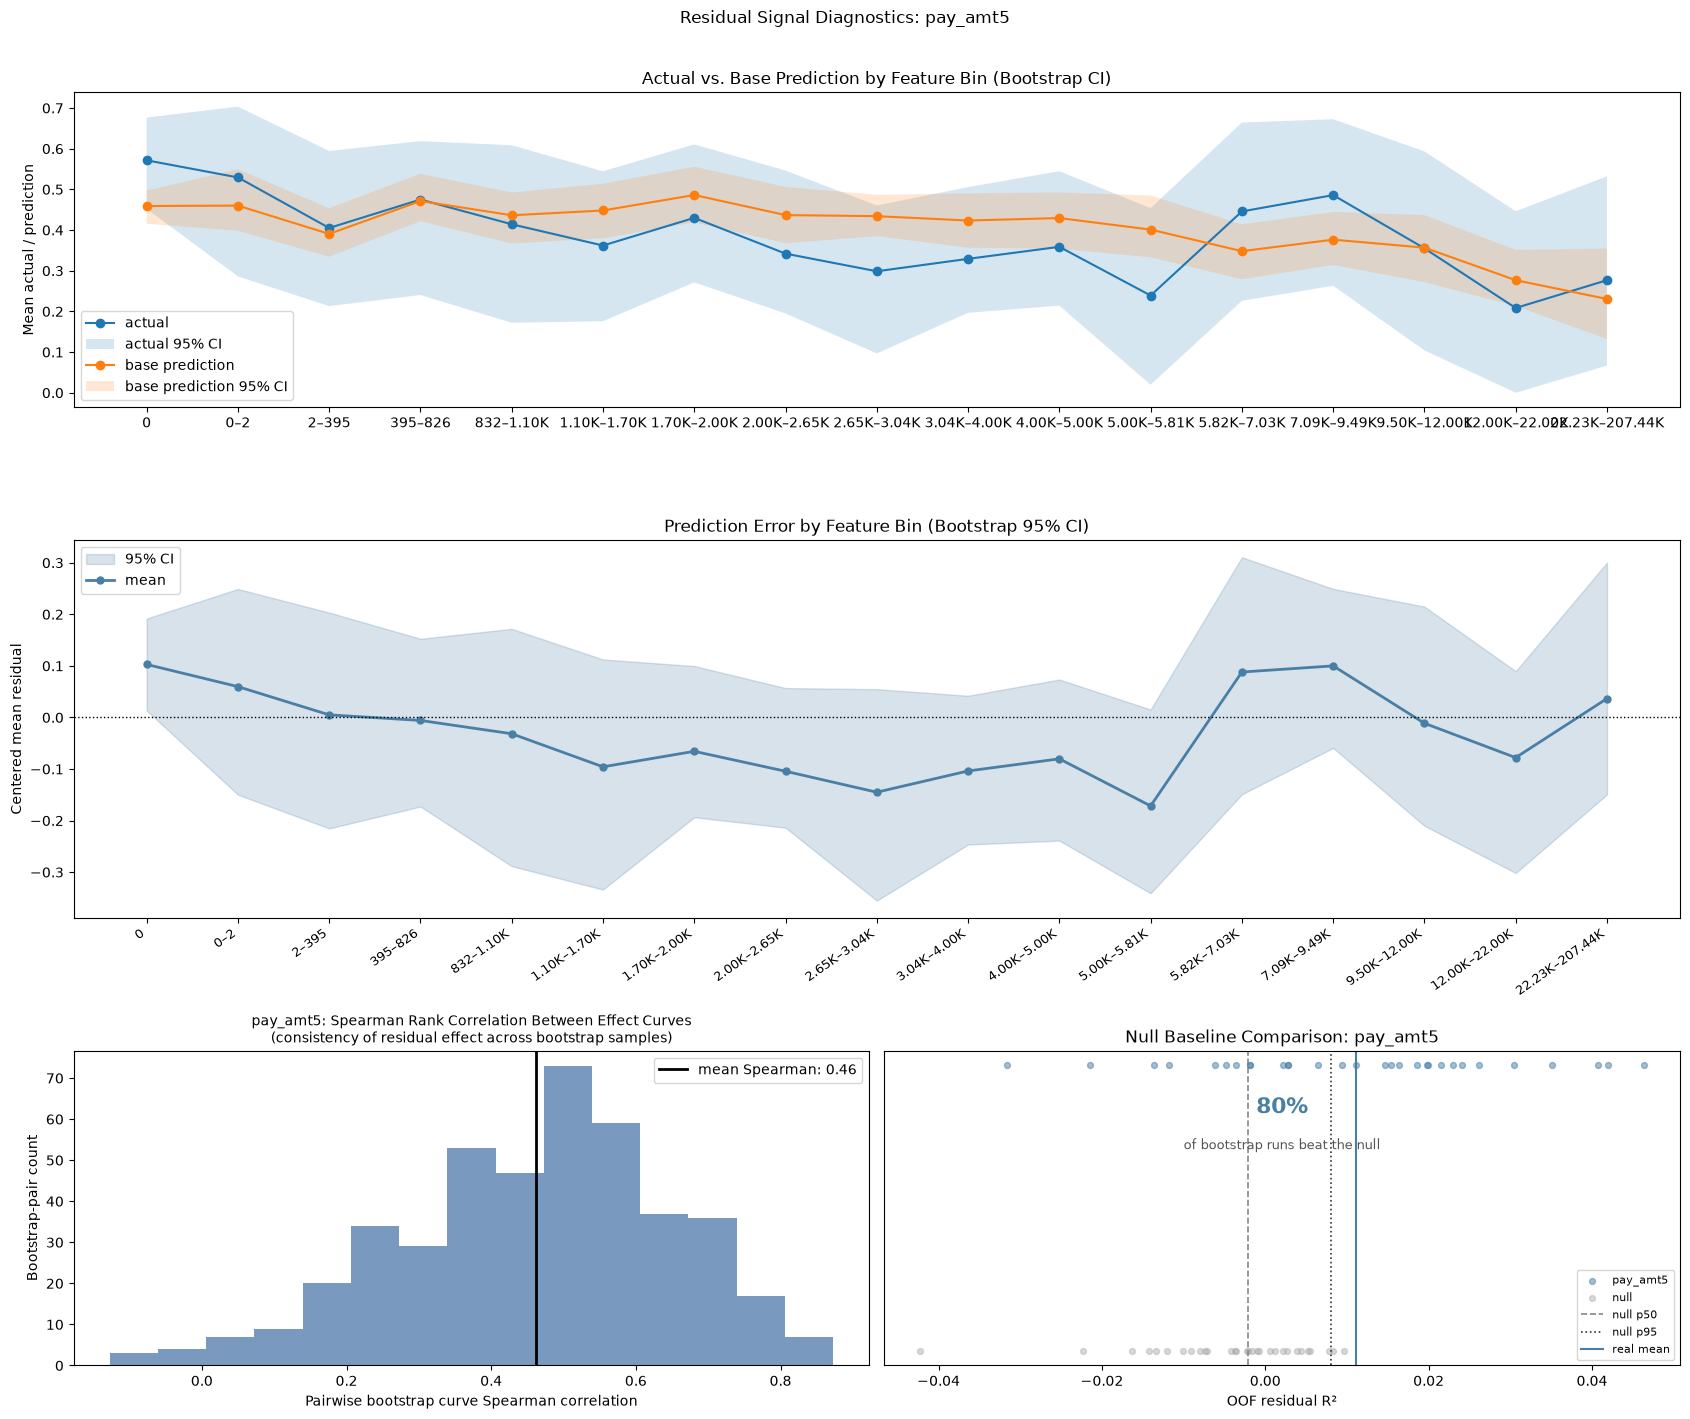

Displaying diagnostics for pay_2


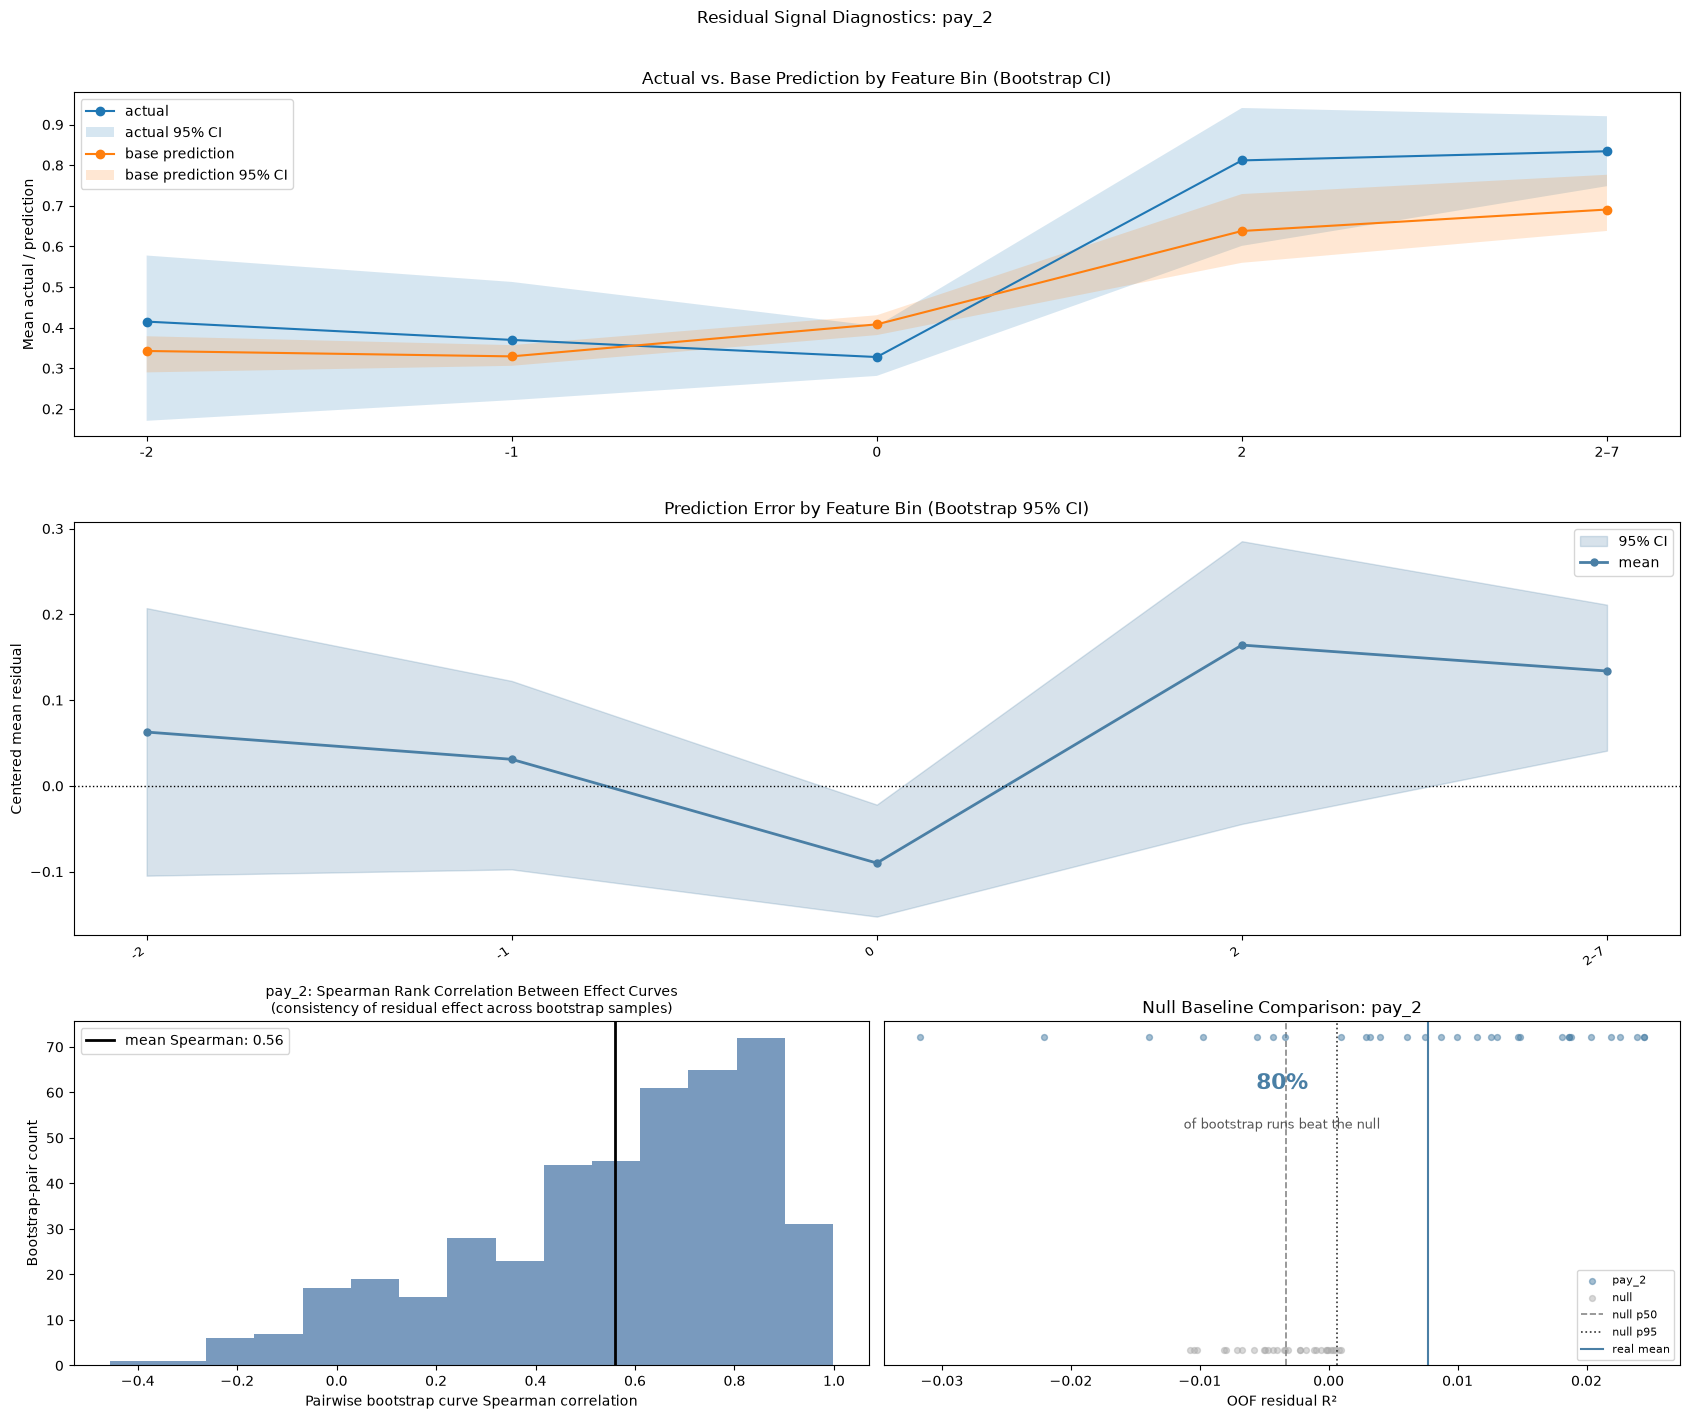

Displaying diagnostics for pay_amt2


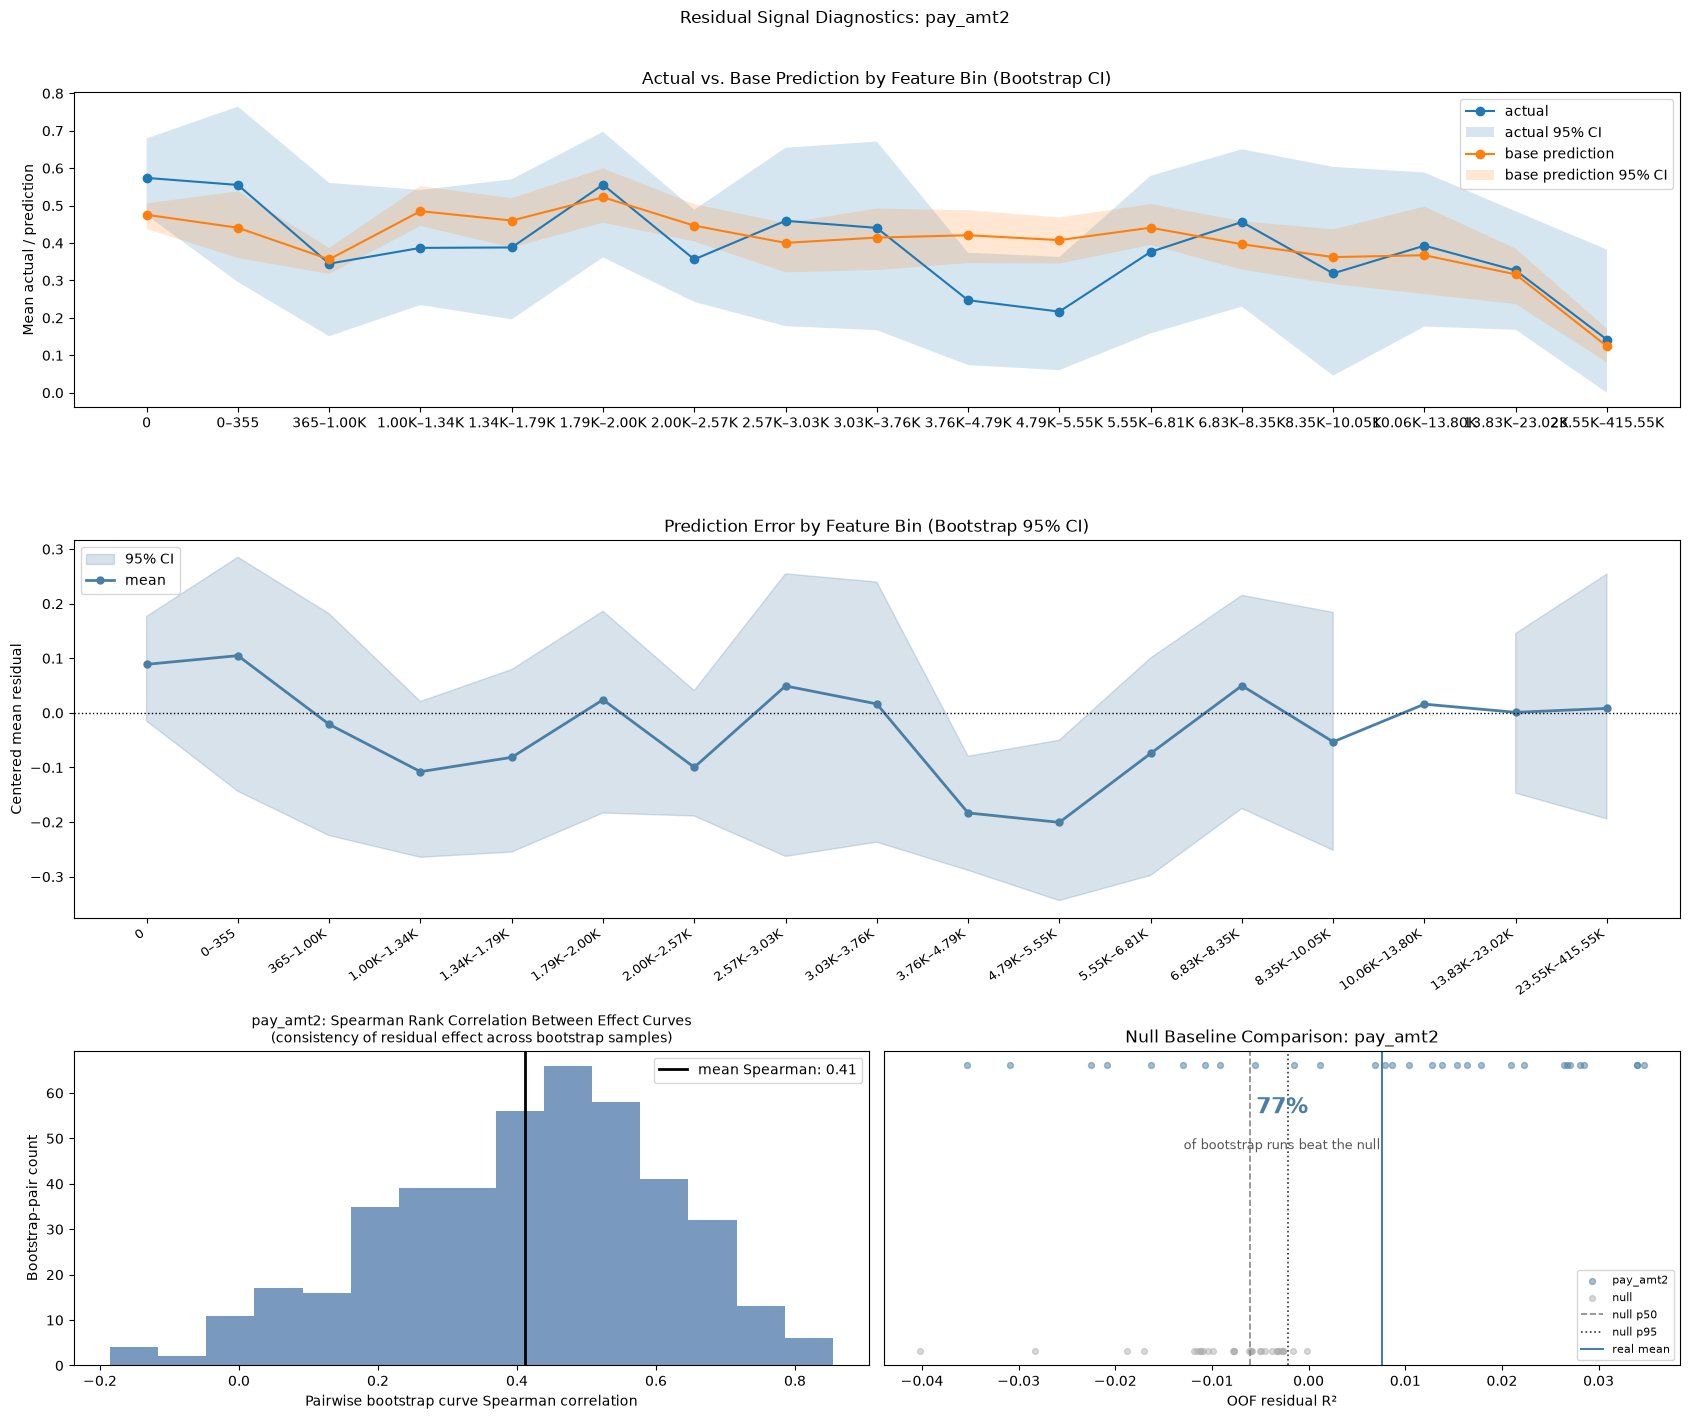

Displaying diagnostics for pay_5


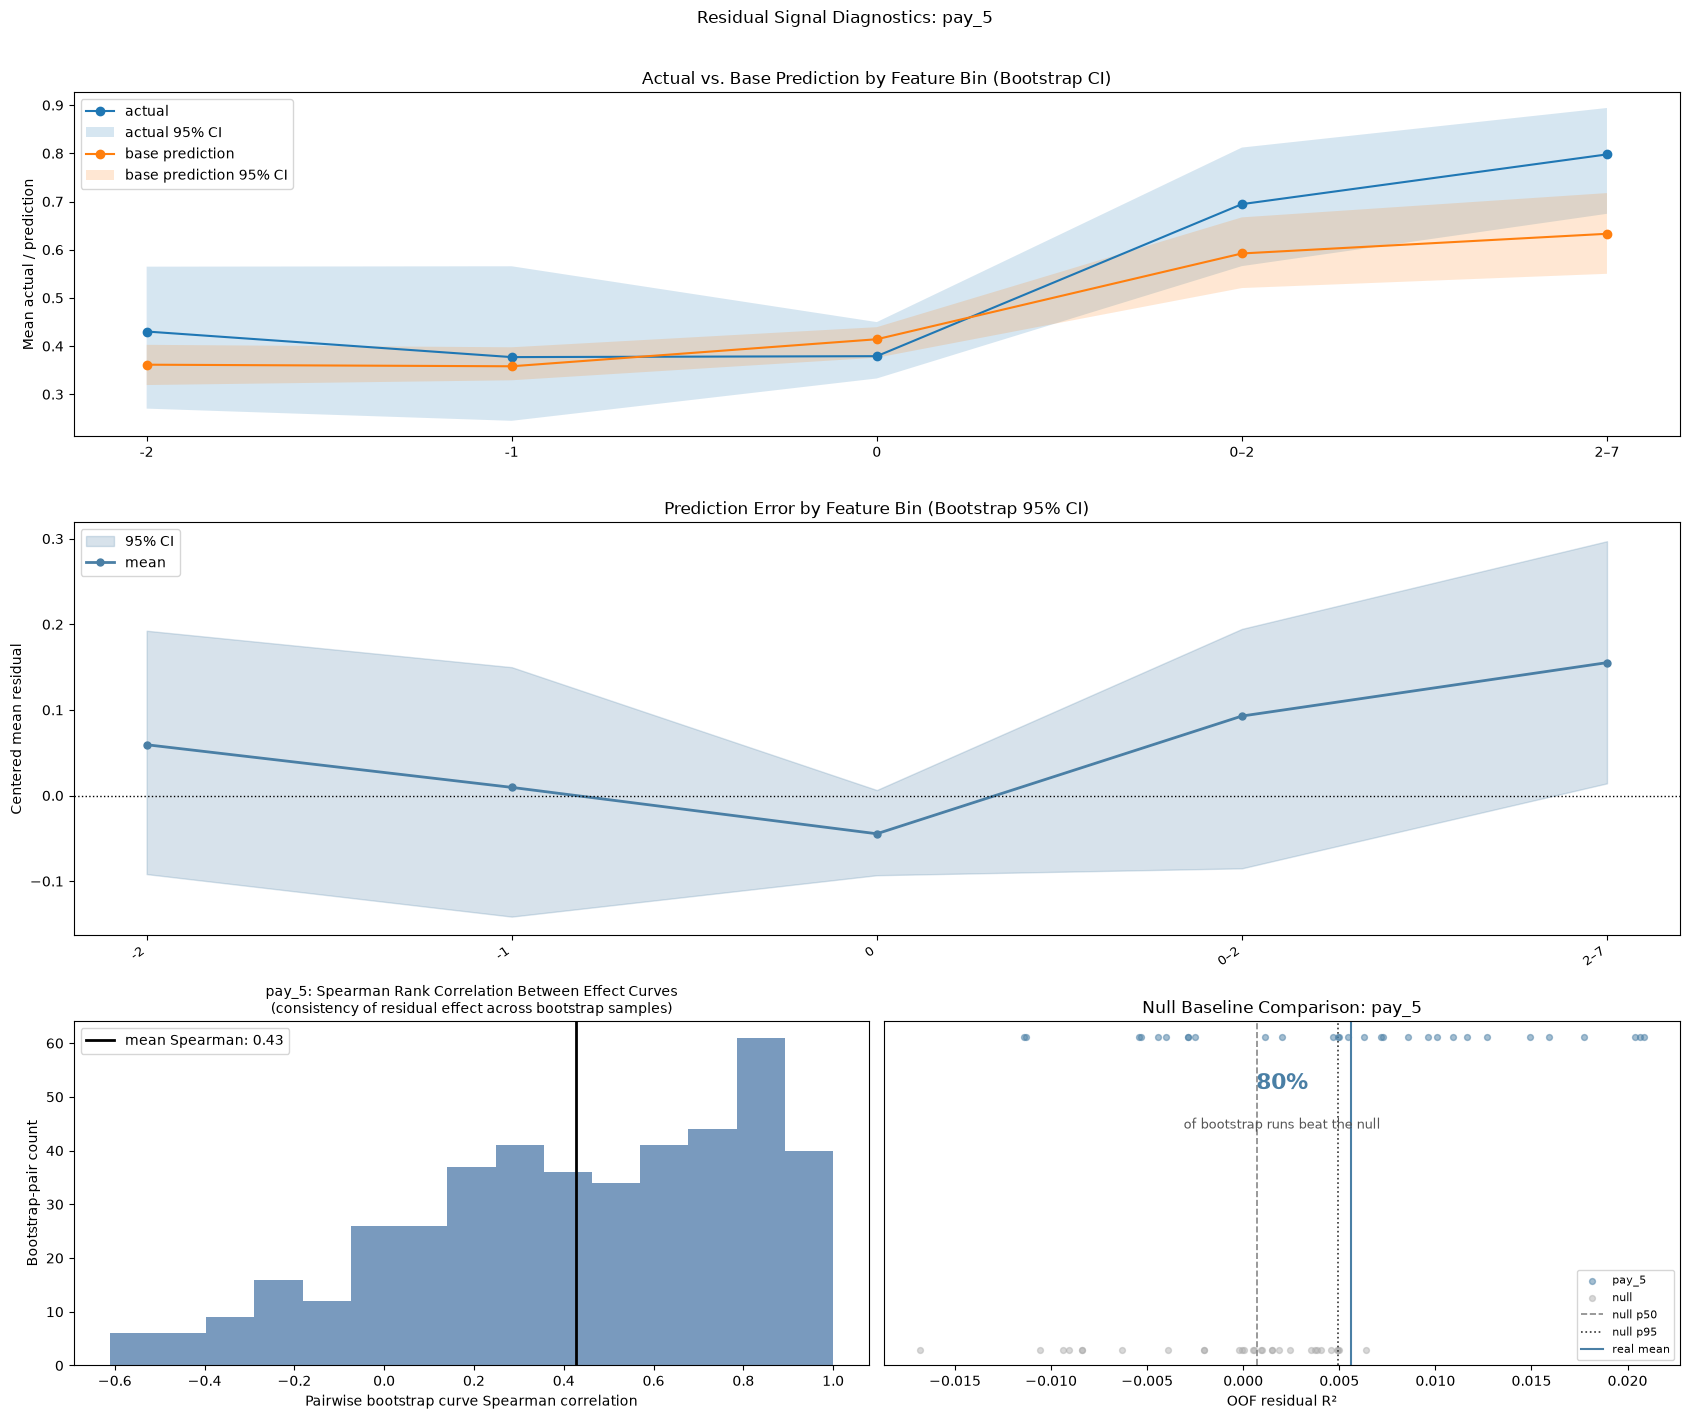

Displaying diagnostics for pay_6


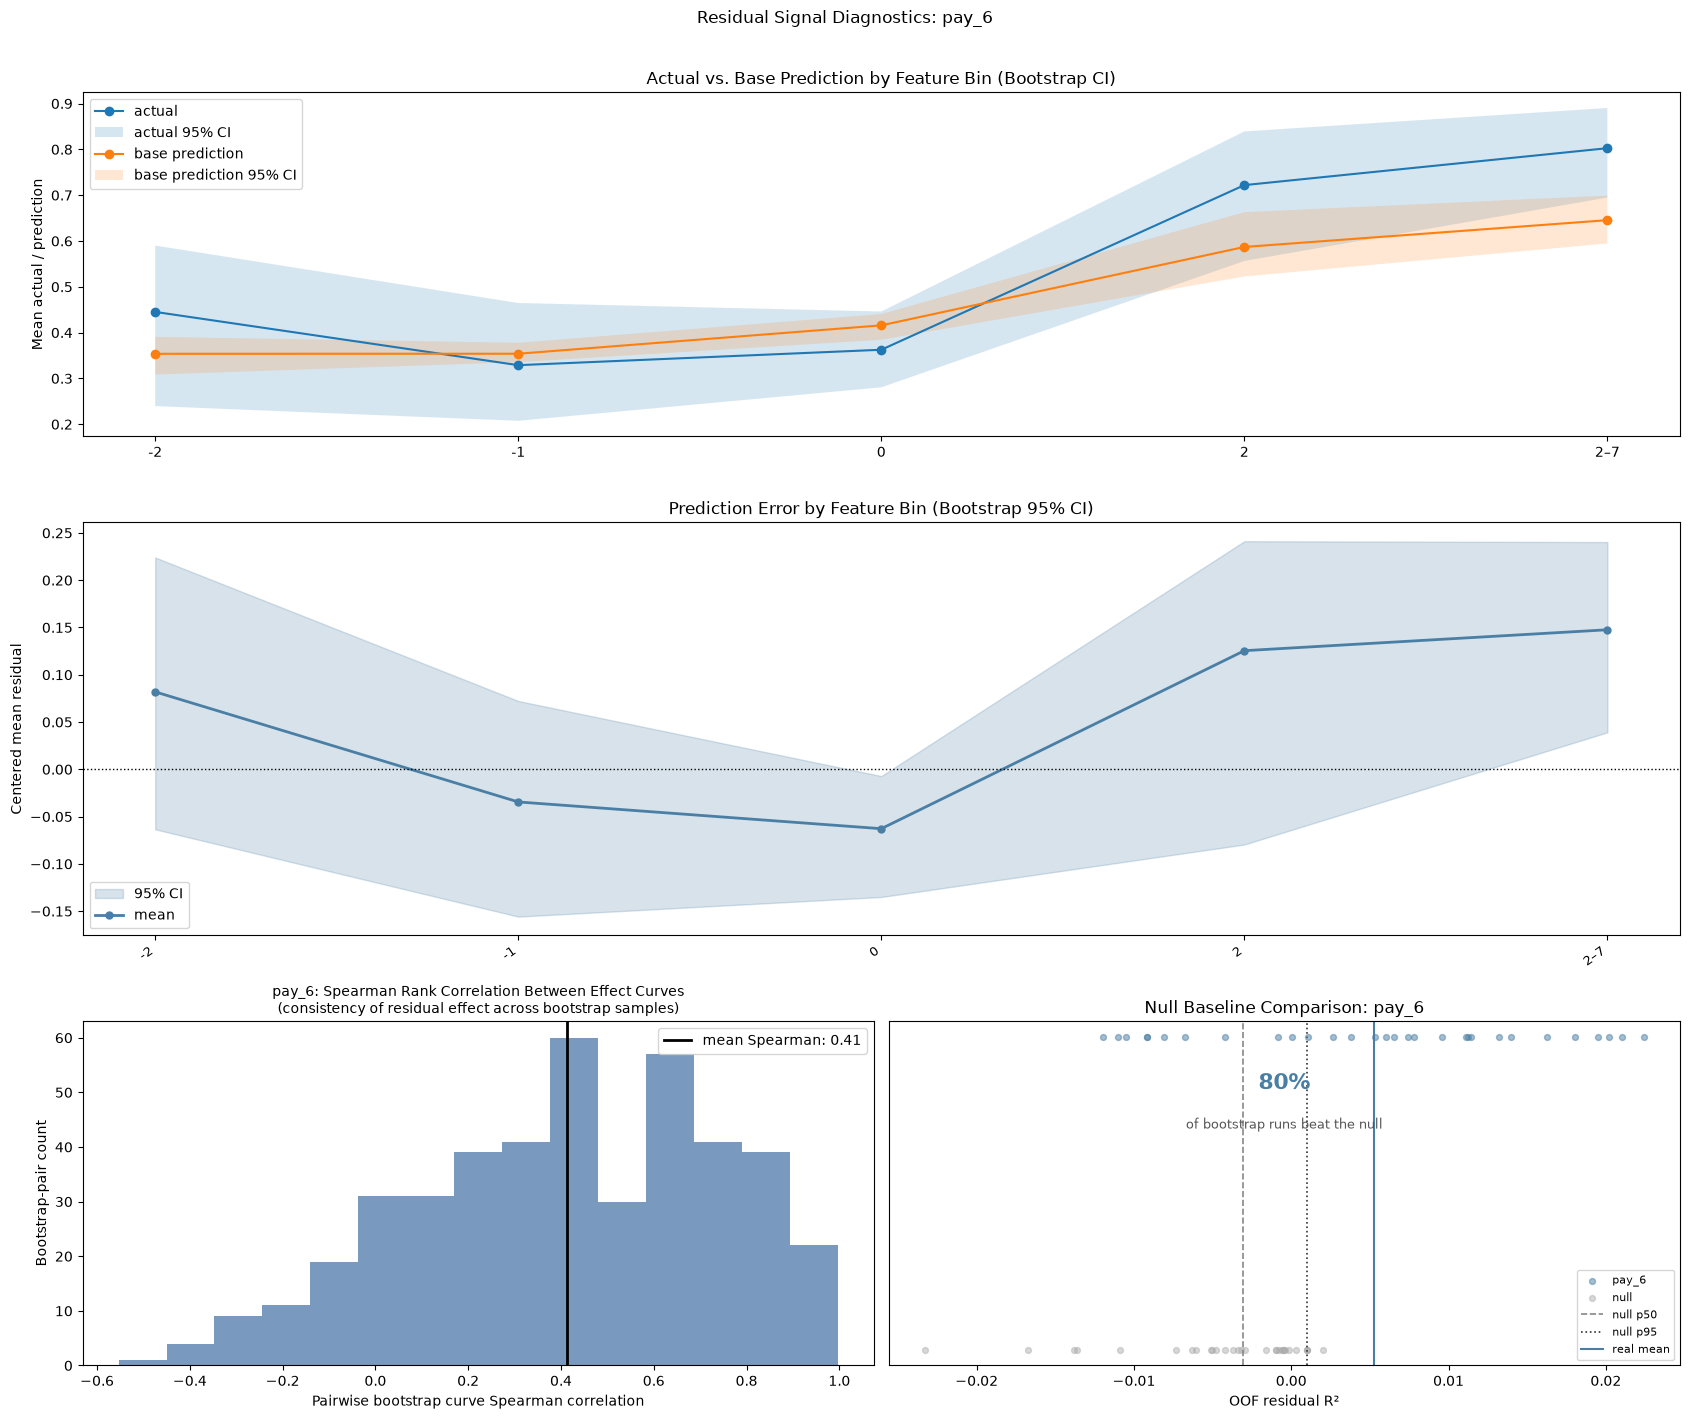

Displaying diagnostics for pay_3


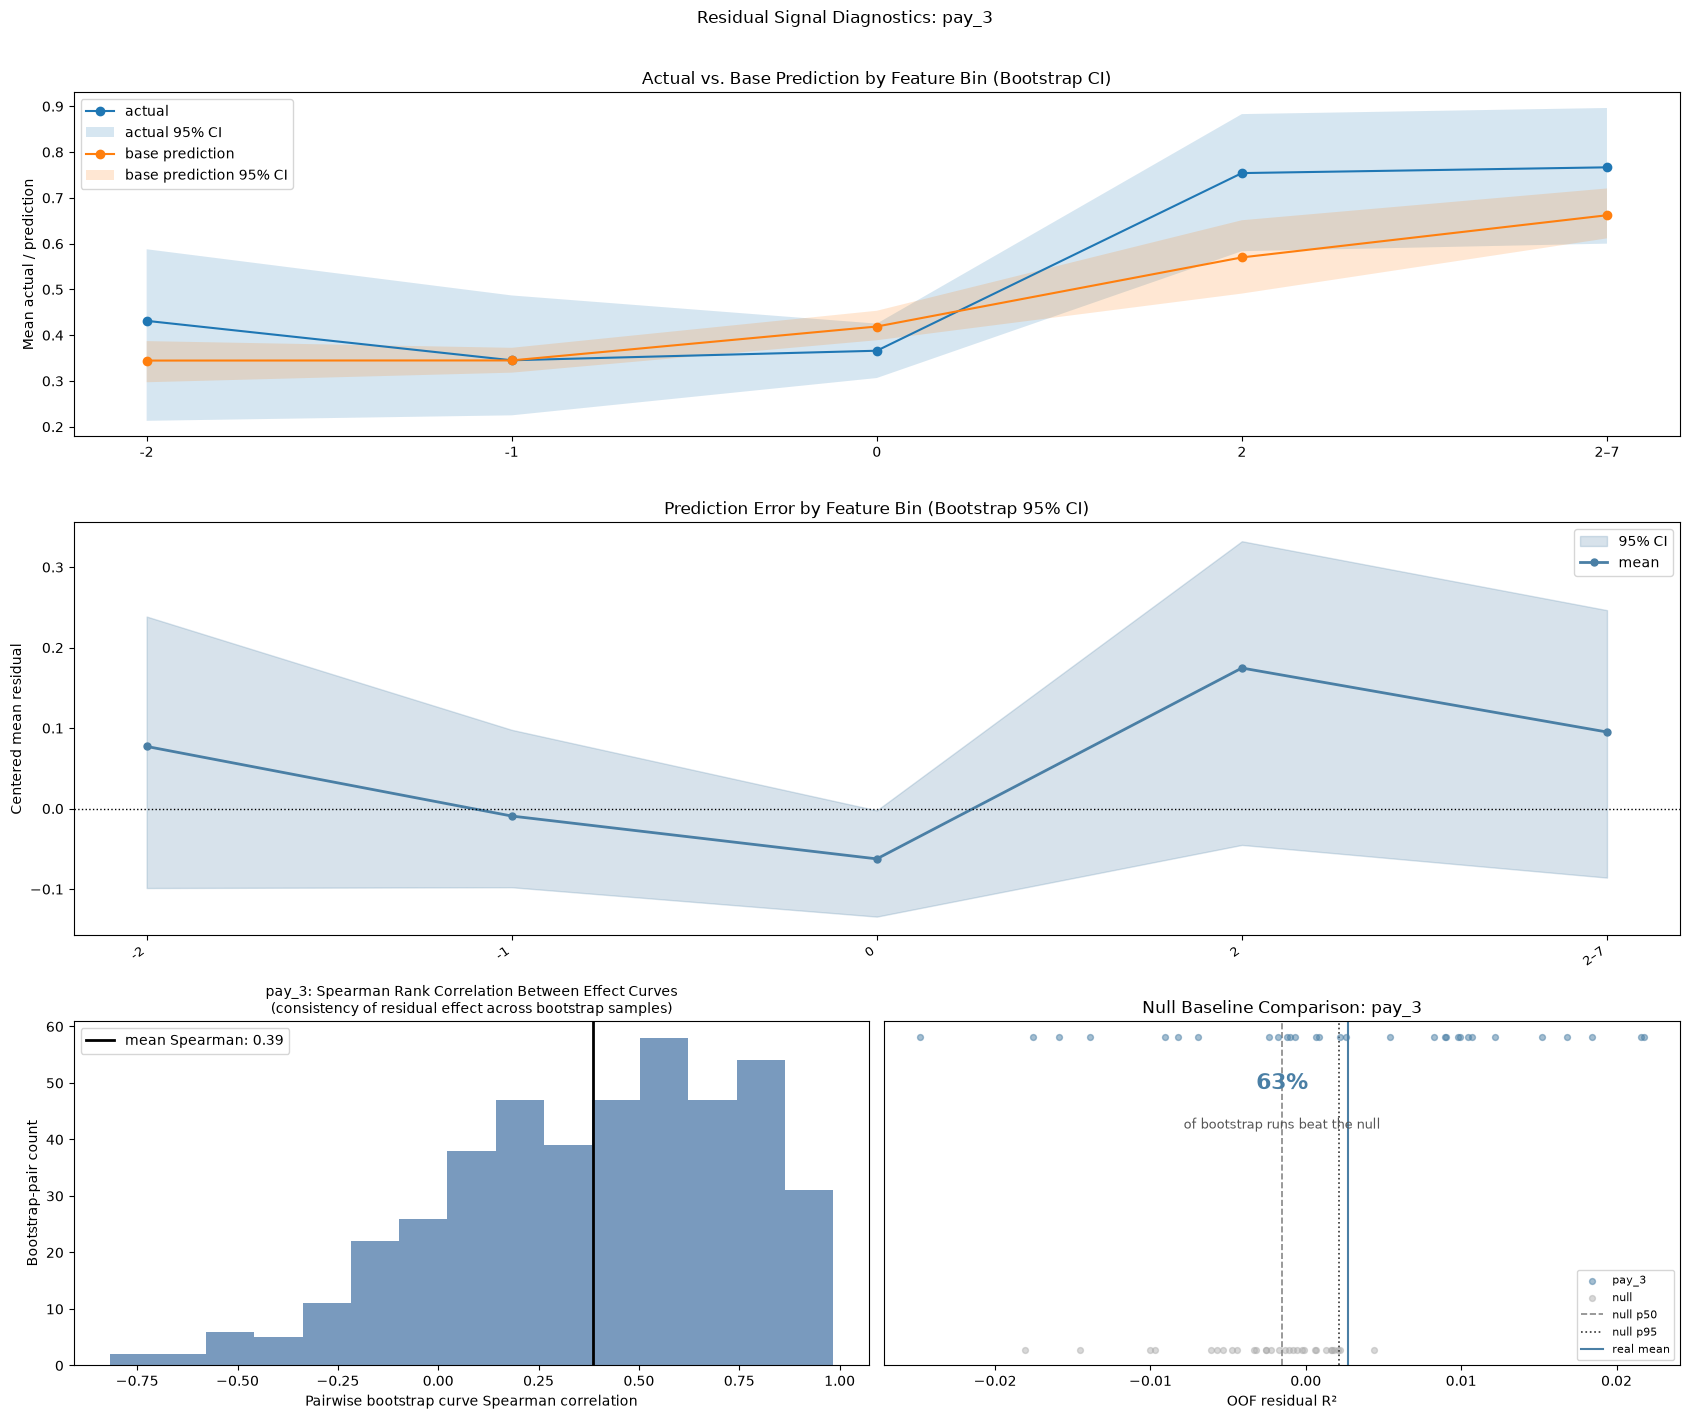

In [ ]:
top_figures = finder.plot_top_features(n=8)
for feature, figure in top_figures.items():
    print(f'Displaying diagnostics for {feature}')
    display(figure)
    plt.close(figure)

## User-supplied split example

This compact run uses the explicit train/validation/holdout labels created earlier.
The `splits=` API accepts TVH dicts or `(train_idx, validation_idx)` tuples.
The summary will show `null_beat_rate` and abs-residual columns even for a single split,
though intervals will be uninformative with only one run.

In [ ]:
compact_features = summary.head(6)['feature'].astype(str).tolist()
tvh_splits = [
    {
        'train': train_rows.index,
        'validation': validation_rows.index,
        'holdout': holdout_rows.index,
    }
]
custom_split_finder = ResidualSignalFinderV2(
    screening_enabled=False,
    univariate_model_type='random_forest',
    n_bootstraps=1,
    n_bins=6,
    random_state=42,
    use_sample_weight=True,
    model_params={'n_estimators': 25, 'max_depth': 3, 'min_samples_leaf': 20},
)
custom_split_finder.fit(
    X_candidates.loc[:, compact_features],
    y=y_true,
    base_pred=oof_pred,
    sample_weight=sample_weight,
    splits=tvh_splits,
    original_model_features=base_feature_cols,
)

display(
    custom_split_finder.get_summary()[
        ['feature', 'mean_oof_residual_r2', 'mean_oof_abs_residual_r2', 'null_beat_rate']
    ]
)
display(custom_split_finder.bootstrap_results_['split_role'].value_counts())

,feature,mean_oof_residual_r2,mean_oof_abs_residual_r2,null_beat_rate
0,pay_0,0.083355,0.049626,1.0
1,pay_2,0.058801,-0.014384,1.0
2,pay_amt2,0.037600,-0.006861,1.0
3,bill_amt1,0.037157,-0.015023,1.0
4,pay_5,0.010081,0.001689,1.0
5,pay_amt5,-0.004470,-0.045349,1.0


split_role
validation    6
holdout       6
Name: count, dtype: int64

## Export HTML report

`to_html()` generates a self-contained single-file HTML report with no external
dependencies. Diagnostic figures are embedded as base64 PNG. The report includes:

- **Residual health** — summary stats (mean, std, RMSE).
- **Feature ranking table** — top-N features with null beat rate badges (color-coded
  by credibility), mean OOF R², variance signal, and curve stability.
- **Feature cards** — one diagnostic figure per top feature.
- **Warnings** — any runtime warnings emitted during fit.

Pass `path=` to write to disk. The method also returns the HTML string for inline use.

In [ ]:
REPORT_PATH = PROJECT_ROOT / 'notebooks' / 'outputs' / 'residual_signal_v2_report.html'
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

html = finder.to_html(
    path=str(REPORT_PATH),
    title='Residual Signal Report — UCI Credit (V2)',
    top_n=5,
)

print(f'Report written to: {REPORT_PATH}')
print(f'HTML size: {len(html):,} bytes')

Report written to: C:\Users\amsac\Desktop\repos\modeling-tools\notebooks\outputs\residual_signal_v2_report.html
HTML size: 1,763,236 bytes


## Interpreting the output

**Mean-signal columns** (primary ranking):
- `mean_oof_residual_r2`: average OOF R² from a univariate residual model. Values > 0.02 in production data typically indicate exploitable signal.
- `p05_oof_residual_r2` / `p95_oof_residual_r2`: bootstrap tail bounds. A wide spread means signal is unstable across splits.

**Credibility columns**:
- `null_beat_rate`: fraction of bootstrap runs where the real feature beat its own permuted copy. > 0.75 = credible, 0.50–0.75 = marginal, < 0.50 = not reliably above noise.
- `beats_null` in `bootstrap_results_`: per-run boolean backing `null_beat_rate`.
- `null_oof_r2` in `bootstrap_results_`: the matched permuted null's OOF R² for that run.

**Variance-signal columns**:
- `mean_oof_abs_residual_r2`: OOF R² from a model fit to `|residuals|`. High values flag features that predict *error magnitude* (heteroscedasticity) even when mean-signal is low.
- `abs_oof_r2` in `bootstrap_results_`: per-run version of the above.

**Stability columns**:
- `median_effect_curve_spearman_stability`: median pairwise Spearman correlation between effect curves across bootstrap pairs. Values near 1.0 mean the shape is consistent. Computed only from bins that were reliable (non-constant) in ≥ 50 % of runs.
- `mean_feature_residual_spearman` / `pct_positive_feature_residual_spearman`: direction and consistency of the feature–residual Spearman correlation. A feature where 100 % of bootstraps show a negative Spearman has a stable, exploitable direction.

**Rank columns**:
- `mean_residual_signal_rank` / `median_residual_signal_rank`: feature's rank position across bootstrap runs. Features with high R² and low rank variance are the most robust candidates.